In [ ]:
import pandas as pd
import numpy as np

# Создаем реалистичный датасет вакансий
data = {
    'job_id': [1, 2, 3, 4, 5, 6, 7, 8],
    'title': ['Junior Data Analyst', 'Data Analyst', 'Senior Data Analyst', 'Junior Data Analyst', 'Data Analyst', 'Junior Data Analyst', 'Data Analyst', 'Data Analyst'],
    'company': ['Яндекс', 'Сбер', 'Тинькофф', 'Ozon', 'Wildberries', 'SmallCorp', 'BigTech', 'Startup'],
    'city': ['Москва', 'Москва', 'Санкт-Петербург', 'Москва', 'Казань', 'Москва', 'Санкт-Петербург', 'Удаленно'],
    'experience': ['Нет опыта', 'От 1 года до 3 лет', 'Более 3 лет', 'Нет опыта', 'От 1 года до 3 лет', 'Нет опыта', 'От 1 года до 3 лет', 'От 1 года до 3 лет'],
    'salary_min': [60000, 120000, 250000, 70000, 90000, 50000, 150000, 110000],
    'salary_max': [90000, 180000, 400000, 100000, 140000, np.nan, 220000, 160000], # Обратите внимание: у job_id 6 пропуск (NaN)
    'skills': ['SQL, Python, Excel', 'SQL, Python, Tableau, A/B', 'SQL, Python, Spark, Airflow', 'SQL, Excel', 'SQL, Python, Power BI', 'Excel', 'SQL, Python, Git', 'SQL, Python'],
    'publish_date': ['2023-10-01', '2023-10-05', '2023-09-20', '2023-10-10', '2023-10-12', '2023-10-15', '2023-09-25', '2023-10-18']
}

df = pd.DataFrame(data)

# Посмотрим на первые 3 строки и типы данных
print("Первые строки:")
display(df.head(3))
print("\nТипы данных:")
print(df.dtypes)

Первые строки:


,job_id,title,company,city,experience,salary_min,salary_max,skills,publish_date
0,1,Junior Data Analyst,Яндекс,Москва,Нет опыта,60000,90000.0,"SQL, Python, Excel",2023-10-01
1,2,Data Analyst,Сбер,Москва,От 1 года до 3 лет,120000,180000.0,"SQL, Python, Tableau, A/B",2023-10-05
2,3,Senior Data Analyst,Тинькофф,Санкт-Петербург,Более 3 лет,250000,400000.0,"SQL, Python, Spark, Airflow",2023-09-20



Типы данных:
job_id            int64
title            object
company          object
city             object
experience       object
salary_min        int64
salary_max      float64
skills           object
publish_date     object
dtype: object


In [ ]:
df['publish_date']=pd.to_datetime(df['publish_date'])
df['publish_month']=df['publish_date'].dt.month
#Найдем мединану для "Нет опыта"
median_no_exp=df.groupby('experience')['salary_max'].median()['Нет опыта']
#Заполним пропуски т перезаписываем колонку
df['salary_max']=df['salary_max'].fillna(median_no_exp)
#df['salary_max']=df.groupby('experience')['salary_max'].transform(lambda x: x.fillna(x.median()))

df_agg=df.groupby('experience')['salary_min'].median()
display(df_agg)







,salary_min
experience,
Более 3 лет,250000.0
Нет опыта,60000.0
От 1 года до 3 лет,115000.0


In [ ]:
#Разбиваем строку по запятой и пробелу
df['skills_list'] = df['skills'].str.split(', ')

#Посмотрим что получилось
print(df['skills_list'].head())

0             [SQL, Python, Excel]
1      [SQL, Python, Tableau, A/B]
2    [SQL, Python, Spark, Airflow]
3                     [SQL, Excel]
4          [SQL, Python, Power BI]
Name: skills_list, dtype: object


In [ ]:
#print(df)
#Разворачиваем списки в отдельные строки
skills_exploded = df['skills_list'].explode()
skills_counts=skills_exploded.value_counts()
#print(skills_counts)





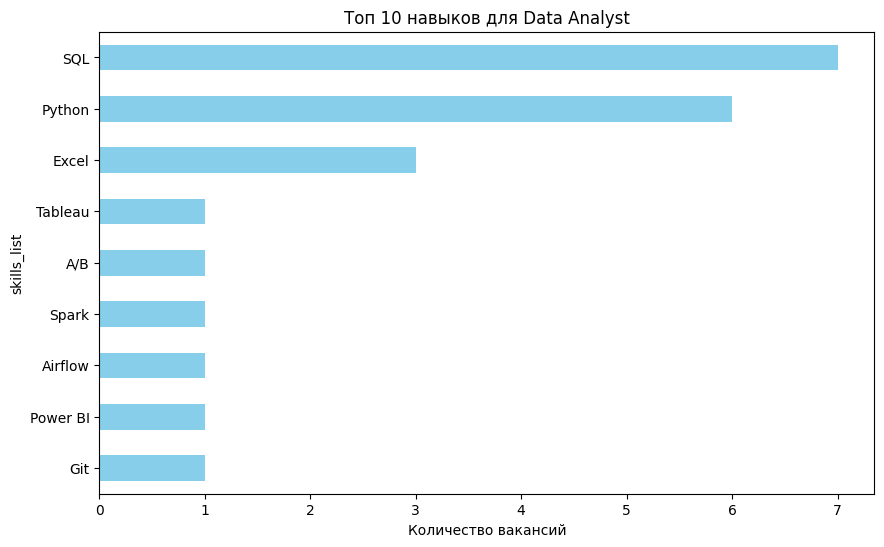

In [ ]:
import matplotlib.pyplot as plt
#Берем топ-10 и строим горизонтальный график
top10 = skills_counts.head(10)
top10.plot(kind='barh',figsize=(10,6),color='skyblue')
plt.title('Топ 10 навыков для Data Analyst')
plt.xlabel('Количество вакансий')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
#Группируем по городу и считаем количество вакансий
city_counts = df.groupby('city').size().sort_values(ascending=False)
print('Количество вакансий по городам')
display(city_counts)

Количество вакансий по городам


,0
city,
Москва,4
Санкт-Петербург,2
Казань,1
Удаленно,1


In [ ]:
#Создаем колонку со средней зарплатой(середина вилки)
df['salary_avg']=(df['salary_min'] + df['salary_max'])/2

#Считаем медиану по городам
city_salary = df.groupby('city')['salary_avg'].median().sort_values(ascending=False)
print('\nМедианная зарплата по городам: ')
display(city_salary)


Медианная зарплата по городам: 


,salary_avg
city,
Санкт-Петербург,255000.0
Удаленно,135000.0
Казань,115000.0
Москва,80000.0


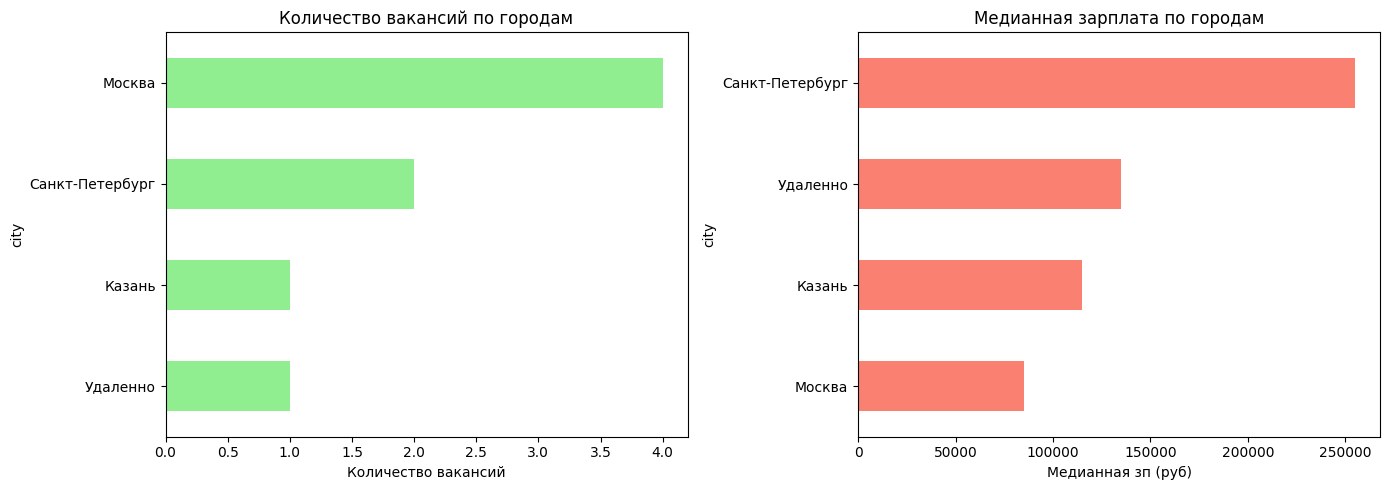

In [ ]:
import matplotlib.pyplot as plt

#Создаем фигуру с двумя графиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

#Левый график: количество вакансий
city_counts.plot(kind='barh', ax=ax1, color='lightgreen')
ax1.set_title('Количество вакансий по городам')
ax1.set_xlabel('Количество вакансий')
ax1.invert_yaxis()

#Правый график: медианная зп
city_salary.plot(kind='barh', ax=ax2, color='salmon')
ax2.set_title('Медианная зарплата по городам')
ax2.set_xlabel('Медианная зп (руб)')
ax2.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
company_counts=df.groupby('company').size().sort_values(ascending=False)
print('Количество вакансий по компаниям: ')
display(company_counts)

Количество вакансий по компаниям: 


,0
company,
BigTech,1
Ozon,1
SmallCorp,1
Startup,1
Wildberries,1
Сбер,1
Тинькофф,1
Яндекс,1


In [ ]:
company_salary = df.groupby('company')['salary_avg'].median().sort_values(ascending=False)
print('\nМедианная зп по компаниям')
print(company_salary)


Мелианная зп по компаниям
company
Тинькофф       325000.0
BigTech        185000.0
Сбер           150000.0
Startup        135000.0
Wildberries    115000.0
Ozon            85000.0
Яндекс          75000.0
SmallCorp       72500.0
Name: salary_avg, dtype: float64


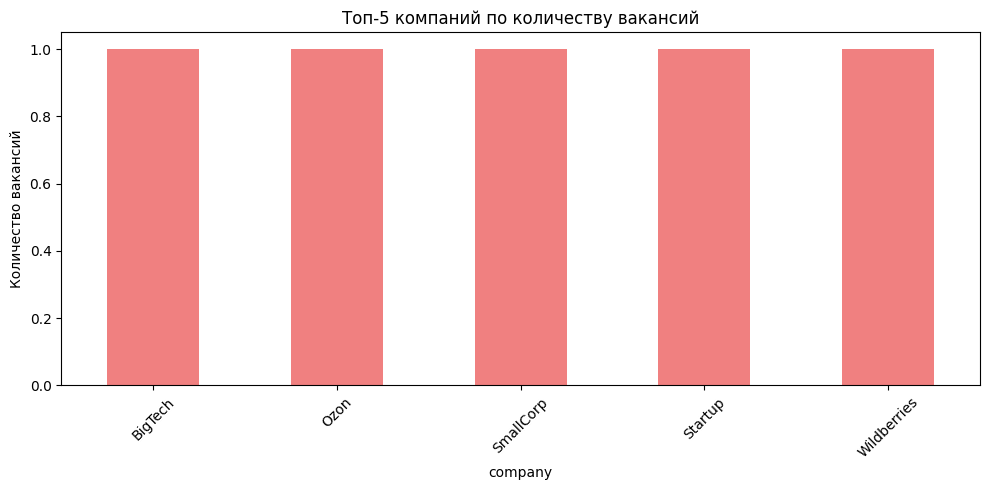

In [ ]:
import matplotlib.pyplot as plt

# Берем топ-5 по количеству вакансий
top_companies = company_counts.head(5)

# Строим график
top_companies.plot(kind='bar', figsize=(10, 5), color='lightcoral')
plt.title('Топ-5 компаний по количеству вакансий')
plt.ylabel('Количество вакансий')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()